In [23]:
import sys
import os
sys.path.append(os.path.abspath('../..'))
from mall_dataset.events_extractor import load_mall_ground_truth, extract_event_timestamps, get_frame_timestamps, extract_significant_events
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from markov_chain_model import (
    extract_states_from_events_list,
    build_transition_matrix,
    stationary_distribution,
    event_sequence,
    build_binary_transition_matrix,
    compute_transition_metrics
)

In [17]:
events_list = get_frame_timestamps("../../mall_dataset/mall_gt.mat", fps=1, significant_events=False)

# Извлекаем полную последовательность состояний
states_true = extract_states_from_events_list(events_list, total_frames=2000)  # укажите total_frames

# Строим матрицу переходов
P_true = build_transition_matrix(states_true)

# Стационарное распределение
pi_true = stationary_distribution(P_true)

# Бинарные события с порогом 3
events_true = event_sequence(states_true, threshold=3)
P_bin_true = build_binary_transition_matrix(events_true)

print("Матрица переходов (первые 5x5):\n", P_true[:5, :5])
print("Стационарное распределение (первые 10):", pi_true[:10])
print("Вероятность события P(1) из бинарной цепи:", np.mean(events_true))

Матрица переходов (первые 5x5):
 [[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
Стационарное распределение (первые 10): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Вероятность события P(1) из бинарной цепи: 0.26113056528264134


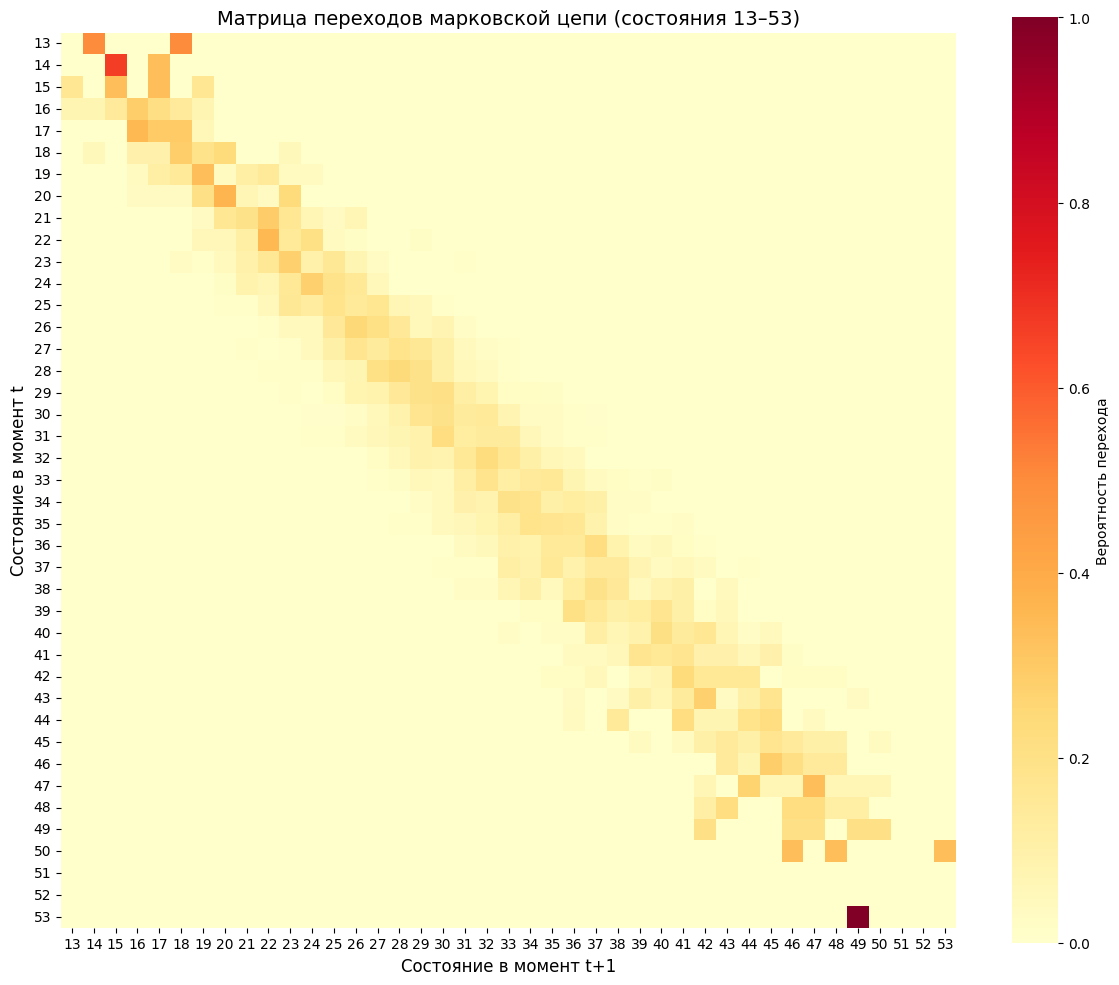

In [ ]:
max_state = int(np.max(states_true))
states_present = np.arange(max_state+1)[np.any(P_true > 0, axis=1)]

min_state = states_present.min()
max_state_vis = states_present.max()
P_vis = P_true[min_state:max_state_vis+1, min_state:max_state_vis+1]

state_labels = list(range(min_state, max_state_vis + 1))

plt.figure(figsize=(12, 10))
sns.heatmap(P_vis,
            cmap='YlOrRd',
            annot=False,
            fmt='.2f',
            cbar_kws={'label': 'Вероятность перехода'},
            square=True,
            xticklabels=state_labels,
            yticklabels=state_labels)

plt.title(f'Матрица переходов марковской цепи (состояния {min_state}–{max_state_vis})', fontsize=14)
plt.xlabel('Состояние в момент t+1', fontsize=12)
plt.ylabel('Состояние в момент t', fontsize=12)

plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

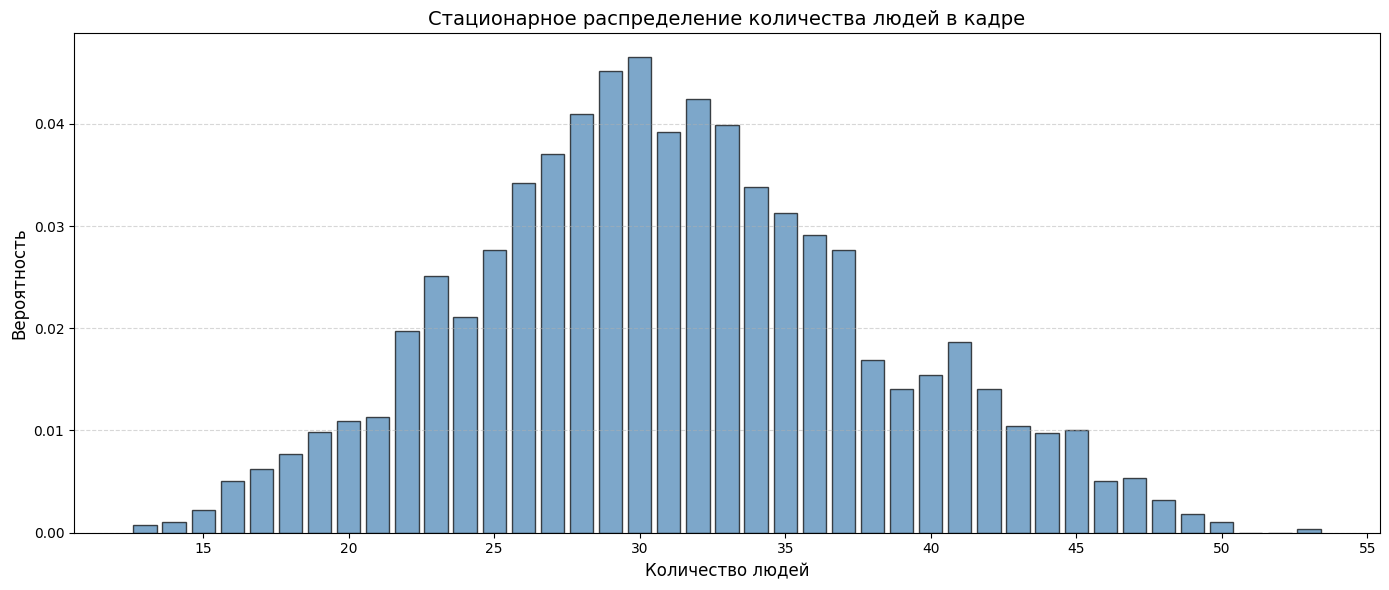

Среднее количество людей в стационарном режиме: 22.48
Мода (наиболее вероятное количество): 30
Доля времени, когда людей > 30: 0.370


In [ ]:
pi = stationary_distribution(P_true)

# Построим график стационарного распределения для состояний, которые реально посещаются
pi_vis = pi[min_state:max_state_vis+1]
states_vis = np.arange(min_state, max_state_vis+1)

plt.figure(figsize=(14, 6))
plt.bar(states_vis, pi_vis, color='steelblue', alpha=0.7, edgecolor='black')
plt.title('Стационарное распределение количества людей в кадре', fontsize=14)
plt.xlabel('Количество людей', fontsize=12)
plt.ylabel('Вероятность', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Дополнительно: вывести несколько статистик
print(f"Среднее количество людей в стационарном режиме: {np.sum(pi * np.arange(len(pi))):.2f}")
print(f"Мода (наиболее вероятное количество): {np.argmax(pi)}")
print(f"Доля времени, когда людей > 30: {np.sum(pi[31:]):.3f}")